In [1]:
import os
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns

%config InlineBackend.figure_format = 'retina'

In [2]:
designs = pd.read_csv('../../data/results/ovo_examples_all.csv.gz', index_col=0)
designs.head()

,pool_id,structure_path,structure_descriptor_key,accepted,spec,contig_index,Sequence B,Sequence L,Sequence H,Sequence A,...,Normalized positive top1 patch area at pH 7.4,Negative patch area at pH 7.4,Normalized negative patch area at pH 7.4,Negative top1 patch area at pH 7.4,Normalized negative top1 patch area at pH 7.4,Electrostatic volume integral at pH 7.4,Positive electrostatic regions volume integral at pH 7.4,Negative electrostatic regions volume integral at pH 7.4,Positive electrostatic volume integral at pH 7.4,Negative electrostatic volume integral at pH 7.4
id,,,,,,,,,,,,,,,,,,,,,
ovo_avz_0030_cycle02,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,EEEEKYEKLAEVALYGNELVESIKDEEEKEKLAKYVLEVIENREKI...,...,0.008814,2397.582566,0.517766,2397.582566,0.517766,-53204.939693,247.264672,-37802.189478,524.728685,-53729.668377
ovo_avz_0124_cycle04,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,KEEELEKLAYEYLEYSIKSYEYKKKAEELEKSEYEDEEKKKKEIEE...,...,0.002133,1329.886461,0.221943,494.351643,0.082502,-29282.013327,1603.259674,-20382.537688,5073.431641,-34355.444969
ovo_avz_0299_cycle01,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,MSIEEIKKILEEIKKEAEAKNAKKVAEAAAKDPELAKKLAAELTAE...,...,0.013346,1431.141721,0.264025,1222.315483,0.225499,-31439.230457,1221.440562,-21455.968271,3326.778095,-34766.008552
ovo_avz_0481_cycle03,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,MEAALKAAEEEKEFQKQVELAKLMIESYKKEGDEEQAEYWEKILEE...,...,0.004164,2322.248872,0.491070,2295.299667,0.485372,-62153.827602,169.365019,-47174.741642,462.410420,-62616.238021
ovo_avz_0732_cycle04,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,EEEEKEKKLKELEKQAKEVEEEGRKKVKEAEAKLKAGDKSEEVKEL...,...,0.026966,1342.739388,0.243623,1156.812464,0.209889,-18930.954449,6064.660410,-19659.415027,11991.801964,-30922.756413


In [3]:
jobs = pd.read_csv('../../data/results/ovo_publication_examples_1_jobs.csv', index_col=0, header=[0, 1])
jobs = jobs.sort_values(by=('Pool', 'name'))
jobs.head()

Pool  \
                                                        name   
('Pool', 'id')                                                 
ogc                 1A41 6*100*8 designs active site weights   
jov                     1A41 6*100*8 designs default weights   
mmo                             4ZXB 1000 designs beta sheet   
avz                        4ZXB 1000 designs default weights   
bbc             4ZXB 1000 designs default weights ligandmpnn   

                                                                     Job  \
                                                      description status   
('Pool', 'id')                                                             
ogc             length 150 with 10-100 residues spacing the ac...   Done   
jov             length 150 with 10-100 residues spacing the ac...   Done   
mmo             Insulin receptor miniprotein binders hotspot E...   Done   
avz             Insulin receptor miniprotein binders hotspot E...   Done   
bbc             Insulin receptor miniprotein binders hotspot E...   Done   

                              Designs       Workflow  \
                     created accepted total    input   
('Pool', 'id')                                         
ogc             4 months ago       26    26      NaN   
jov             4 months ago        0     0      NaN   
mmo             4 months ago        1     1      NaN   
avz             4 months ago        5     5      NaN   
bbc             3 months ago        3     3      NaN   

                                             \
                                       type   
('Pool', 'id')                                
ogc             RFdiffusion scaffold design   
jov             RFdiffusion scaffold design   
mmo               RFdiffusion binder design   
avz               RFdiffusion binder design   
bbc               RFdiffusion binder design   

                                                      RFdiffusion  \
                                                          contigs   
('Pool', 'id')                                                      
ogc             ['10-100/A56-56/10-100/A100-100/10-100/A125-12...   
jov             ['10-100/A56-56/10-100/A100-100/10-100/A125-12...   
mmo                                           ['E6-155/0 50-100']   
avz                                           ['E6-155/0 50-100']   
bbc                                           ['E6-155/0 50-100']   

                             ...               BindCraft                   \
                   hotspots  ... number_of_final_designs time_limit_hours   
('Pool', 'id')               ...                                            
ogc                     NaN  ...                     NaN              NaN   
jov                     NaN  ...                     NaN              NaN   
mmo             E64,E88,E96  ...                     NaN              NaN   
avz             E64,E88,E96  ...                     NaN              NaN   
bbc             E64,E88,E96  ...                     NaN              NaN   

                                                               \
               filter_type design_protocol interface_protocol   
('Pool', 'id')                                                  
ogc                    NaN             NaN                NaN   
jov                    NaN             NaN                NaN   
mmo                    NaN             NaN                NaN   
avz                    NaN             NaN                NaN   
bbc                    NaN             NaN                NaN   

                                                                               \
               template_protocol prediction_protocol custom_advanced_settings   
('Pool', 'id')                                                                  
ogc                          NaN                 NaN                      NaN   
jov                          NaN                 NaN                      NaN   
mmo         

In [4]:
scaffold_jobs = jobs[jobs[('Workflow','type')] == 'RFdiffusion scaffold design']

In [5]:
scaffold_jobs[[
    ('Pool','name'), ('RFdiffusion', 'contigs'), ('RFdiffusion', 'num_designs'), 
    ('ProteinMPNN', 'num_sequences'), 
]]

Pool  \
                                                         name   
('Pool', 'id')                                                  
ogc                  1A41 6*100*8 designs active site weights   
jov                      1A41 6*100*8 designs default weights   
zuk                          5IUS 500*5 designs PD1 interface   
xeh             5IUS 500*5 designs PD1 interface with inpaint   

                                                      RFdiffusion              \
                                                          contigs num_designs   
('Pool', 'id')                                                                  
ogc             ['10-100/A56-56/10-100/A100-100/10-100/A125-12...       100.0   
jov             ['10-100/A56-56/10-100/A100-100/10-100/A125-12...       100.0   
zuk             ['0-30/A119-140/15-40/A63-82/0-30/0 C18-27/C53...      1000.0   
xeh             ['0-30/A119-140/15-40/A63-82/0-30/0 C18-27/C53...      1000.0   

                 ProteinMPNN  
               num_sequences  
('Pool', 'id')                
ogc                      8.0  
jov                      2.0  
zuk                      5.0  
xeh                      5.0

In [6]:
scaffold_jobs[['Pool','Designs', 'Thresholds']].dropna(how='all', axis=1)

Pool  \
                                                         name   
('Pool', 'id')                                                  
ogc                  1A41 6*100*8 designs active site weights   
jov                      1A41 6*100*8 designs default weights   
zuk                          5IUS 500*5 designs PD1 interface   
xeh             5IUS 500*5 designs PD1 interface with inpaint   

                                                                   Designs  \
                                                      description accepted   
('Pool', 'id')                                                               
ogc             length 150 with 10-100 residues spacing the ac...       26   
jov             length 150 with 10-100 residues spacing the ac...        0   
zuk                           PD1 interface, no sequence redesign        1   
xeh                                    PD1 interface, inpaint seq      275   

                          Thresholds                                           
               total AF2 Design RMSD AF2 Native Motif RMSD  AF2 PAE AF2 pLDDT  
('Pool', 'id')                                                                 
ogc               26         ≤ 2.000               ≤ 1.500  ≤ 5.000  ≥ 80.000  
jov                0         ≤ 2.000               ≤ 1.500  ≤ 5.000  ≥ 80.000  
zuk                1         ≤ 2.000               ≤ 2.000  ≤ 5.000  ≥ 80.000  
xeh              275         ≤ 2.000               ≤ 2.000  ≤ 5.000  ≥ 80.000

For oxidoreductase motif scaffolding, PDB 1A4I chain A residues 56, 100 and 125 were used as fixed input motif, generating 10 to 100 residues in between and on N/C termini, with a restriction of desired length of exactly 150 amino acids. In total, 100 backbones * 6 permutations of the order of the three fixed residues * 8 sequence designs were generated, totalling at 4800 designed sequences which were filtered with AlphaFold2 (PAE < 5, pLDDT > 80, Design RMSD < 2 A and Native Motif RMSD < 1.5), resulting in 13 accepted designs when RFdiffusion active site weights were employed. Running the same workflow with default RFDiffusion weights yielded no accepted designs due to higher Native Motif RMSD.



In [7]:
interface_designs = designs[designs['pool_id'].isin(['zuk', 'xeh'])]
interface_designs.head()

,pool_id,structure_path,structure_descriptor_key,accepted,spec,contig_index,Sequence B,Sequence L,Sequence H,Sequence A,...,Normalized positive top1 patch area at pH 7.4,Negative patch area at pH 7.4,Normalized negative patch area at pH 7.4,Negative top1 patch area at pH 7.4,Normalized negative top1 patch area at pH 7.4,Electrostatic volume integral at pH 7.4,Positive electrostatic regions volume integral at pH 7.4,Negative electrostatic regions volume integral at pH 7.4,Positive electrostatic volume integral at pH 7.4,Negative electrostatic volume integral at pH 7.4
id,,,,,,,,,,,,,,,,,,,,,
ovo_xeh_0008_seq02,xeh,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|ligandmpnn|sequence_structure_path,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,AALYESRDVRVGEINLSDKISIRESPRVHTETQAETDAAVAAAMAA...,...,0.026279,683.348839,0.111084,370.301777,0.060195,-10240.110952,6687.920601,-12414.339797,13125.230207,-23365.341159
ovo_xeh_0023_seq04,xeh,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|ligandmpnn|sequence_structure_path,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,APAGDLRIGVIFLDDKIHIEESPRVPDDSPEARERLLAQGVAILQQ...,...,0.011018,1101.154542,0.184330,365.199421,0.061133,-19816.273257,2295.776046,-13715.433234,5402.875865,-25219.149122
ovo_xeh_0025_seq05,xeh,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|ligandmpnn|sequence_structure_path,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,ADAVAQVTALLERAAREEGLESLDVRMGVISLSKKISIEESPRRRV...,...,0.004040,2075.170957,0.333473,1266.028591,0.203447,-39230.856128,1195.796487,-26765.925576,3002.076573,-42232.932701
ovo_xeh_0026_seq03,xeh,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|ligandmpnn|sequence_structure_path,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,PVLGPREPSDFDIRAGLINLKDKISIEETPRVWADRGPRGHDAFAQ...,...,0.013014,980.792725,0.155169,295.232611,0.046708,-19787.057802,2511.788356,-14040.251232,6280.290531,-26067.348333
ovo_xeh_0029_seq03,xeh,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|ligandmpnn|sequence_structure_path,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,PYFPEVDPESDVRFGVIHLDDKISIEESPRIKNSDVEKINAALAAM...,...,0.001755,1105.045041,0.239445,639.316527,0.138529,-24650.734607,502.436116,-14994.144542,1671.549197,-26322.283804


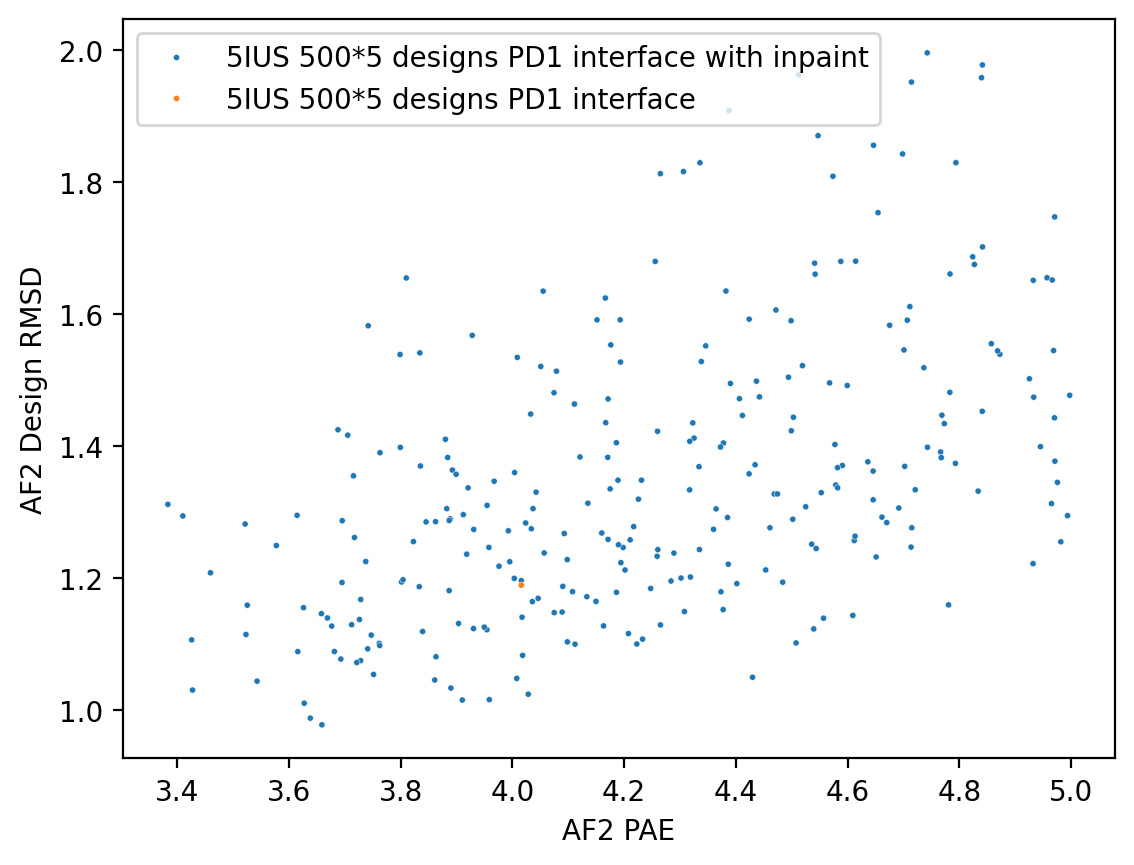

In [8]:
hue = jobs[('Pool','name')].loc[interface_designs.pool_id]
sns.scatterplot(interface_designs, x='AF2 PAE', y='AF2 Design RMSD', hue=hue.values, s=5);

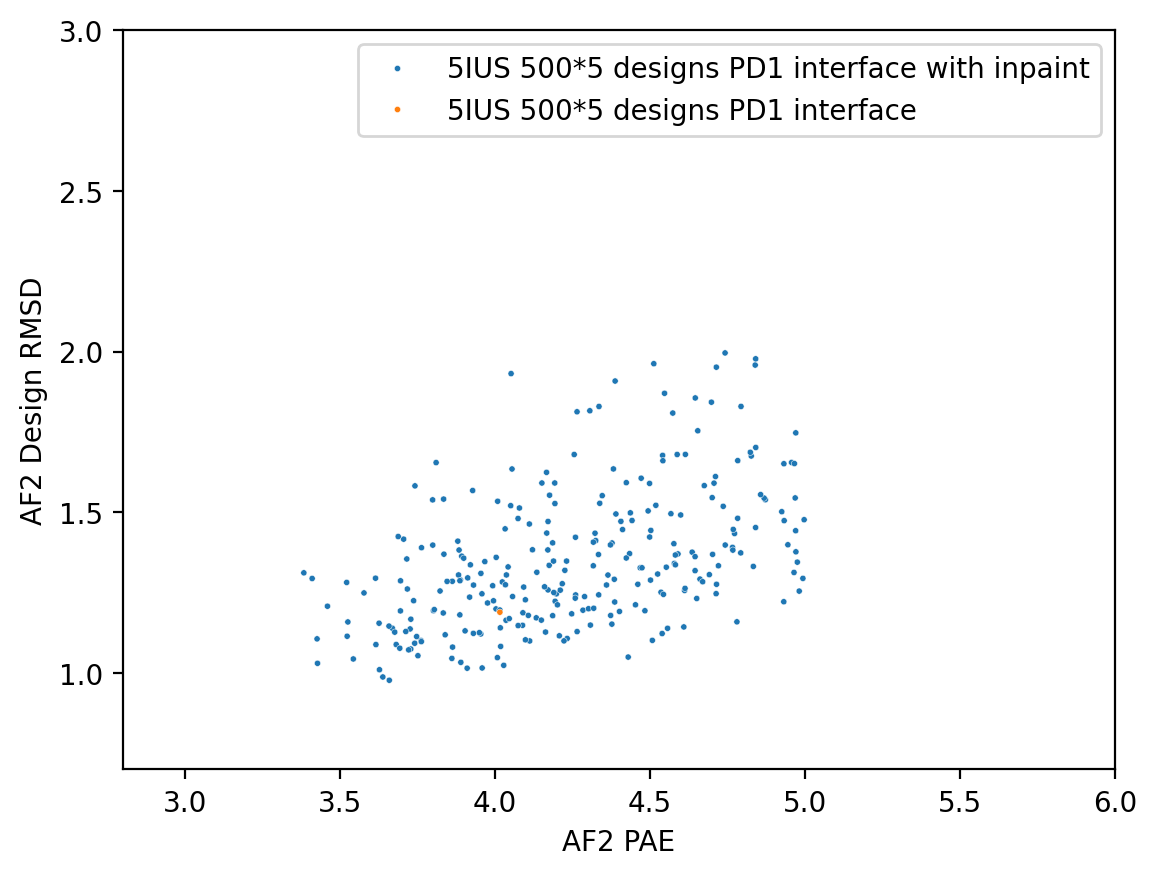

In [9]:
ax = sns.scatterplot(interface_designs, x='AF2 PAE', y='AF2 Design RMSD', hue=hue.values, s=5);
ax.set_xlim([2.8, 6]);
ax.set_ylim([0.7, 3]);

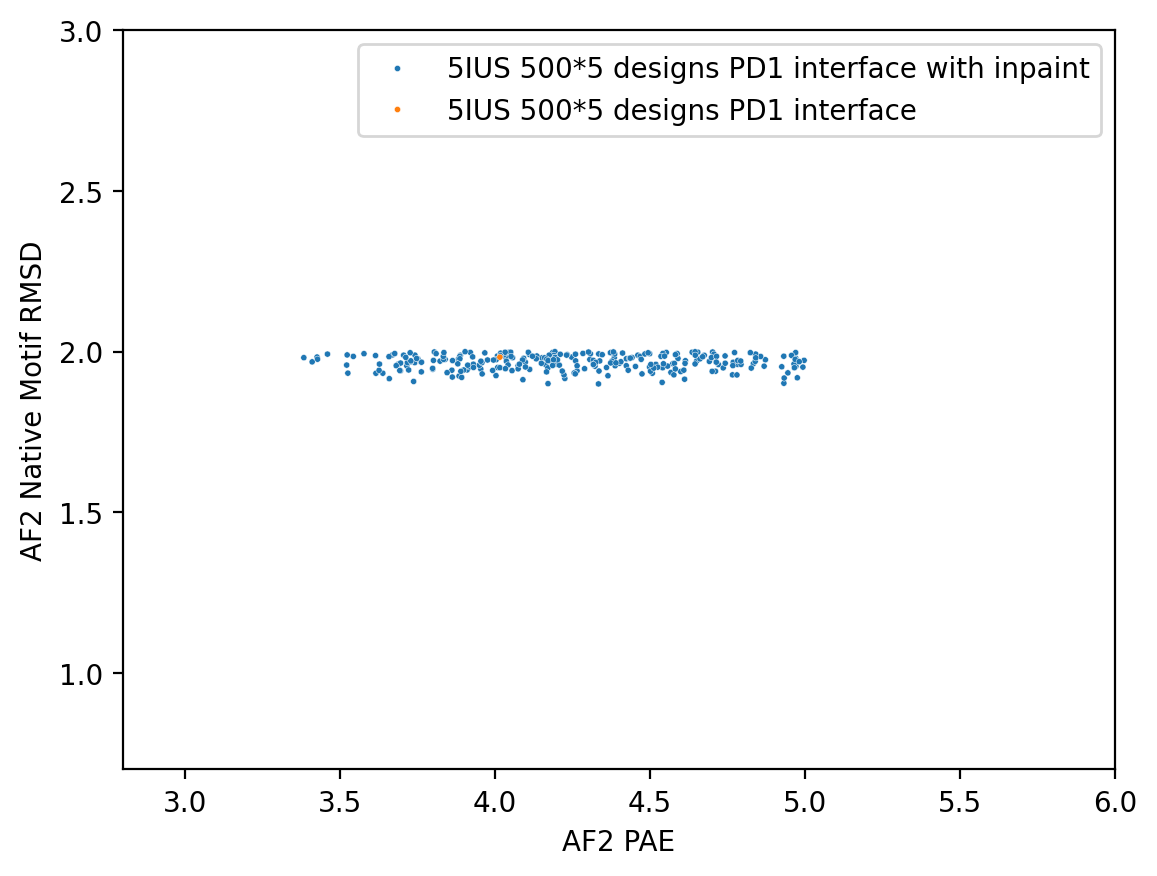

In [10]:
ax = sns.scatterplot(interface_designs, x='AF2 PAE', y='AF2 Native Motif RMSD', hue=hue.values, s=5);
ax.set_xlim([2.8, 6]);
ax.set_ylim([0.7, 3]);

For PD-1 interface scaffolding, PDB 5IUS chain A segments 119-140 and 63-82 were joined with 15 to 40 generated residues, with additional 0 to 30 residues generated on N/C termini. Residues facing away from the interface masked to RFdiffusion using sequence inpainting and redesigned with ProteinMPNN to allow for better packing against the designed scaffold. In total, 1000 backbones * 5 sequence designs were generated, totaling at 5000 designed sequences, which were filtered with AlphaFold2 (PAE < 5, pLDDT > 80, Design RMSD < 2 A and Native Motif RMSD < 2), resulting in 275 accepted designs. Running the same workflow without inpainting yielded only 1 accepted design, although this was mostly due to higher native motif RMSD of the inward-facing residues where the sidechains are expected to move, so a less stringent threshold could be applied.


In [11]:
rf_binder_jobs = jobs.loc[['mmo','avz']]

In [12]:
rf_binder_jobs[[
    ('Pool','name'), ('RFdiffusion', 'contigs'), ('RFdiffusion', 'hotspots'), ('RFdiffusion', 'num_designs'), 
    ('ProteinMPNN', 'num_sequences'), ('ProteinMPNN', 'fastrelax_cycles')
]]

Pool          RFdiffusion  \
                                             name              contigs   
('Pool', 'id')                                                           
mmo                  4ZXB 1000 designs beta sheet  ['E6-155/0 50-100']   
avz             4ZXB 1000 designs default weights  ['E6-155/0 50-100']   

                                          ProteinMPNN                   
                   hotspots num_designs num_sequences fastrelax_cycles  
('Pool', 'id')                                                          
mmo             E64,E88,E96      1000.0           1.0              3.0  
avz             E64,E88,E96      1000.0           1.0              3.0

In [13]:
rf_binder_jobs[['Pool', 'Designs', 'Thresholds']].dropna(how='all', axis=1)

Pool  \
                                             name   
('Pool', 'id')                                      
mmo                  4ZXB 1000 designs beta sheet   
avz             4ZXB 1000 designs default weights   

                                                                   Designs  \
                                                      description accepted   
('Pool', 'id')                                                               
mmo             Insulin receptor miniprotein binders hotspot E...        1   
avz             Insulin receptor miniprotein binders hotspot E...        5   

                     Thresholds                                 \
               total   AF2 iPAE AF2 Target-aligned Binder RMSD   
('Pool', 'id')                                                   
mmo                1   ≤ 10.000                        ≤ 2.000   
avz                5   ≤ 10.000                        ≤ 2.000   

                                             
               AF2 Binder pLDDT Rosetta ddG  
('Pool', 'id')                               
mmo                    ≥ 80.000   ≤ -20.000  
avz                    ≥ 80.000   ≤ -20.000

In [14]:
rf_binder_designs = designs[designs.pool_id.isin(['mmo','avz','bbc'])]

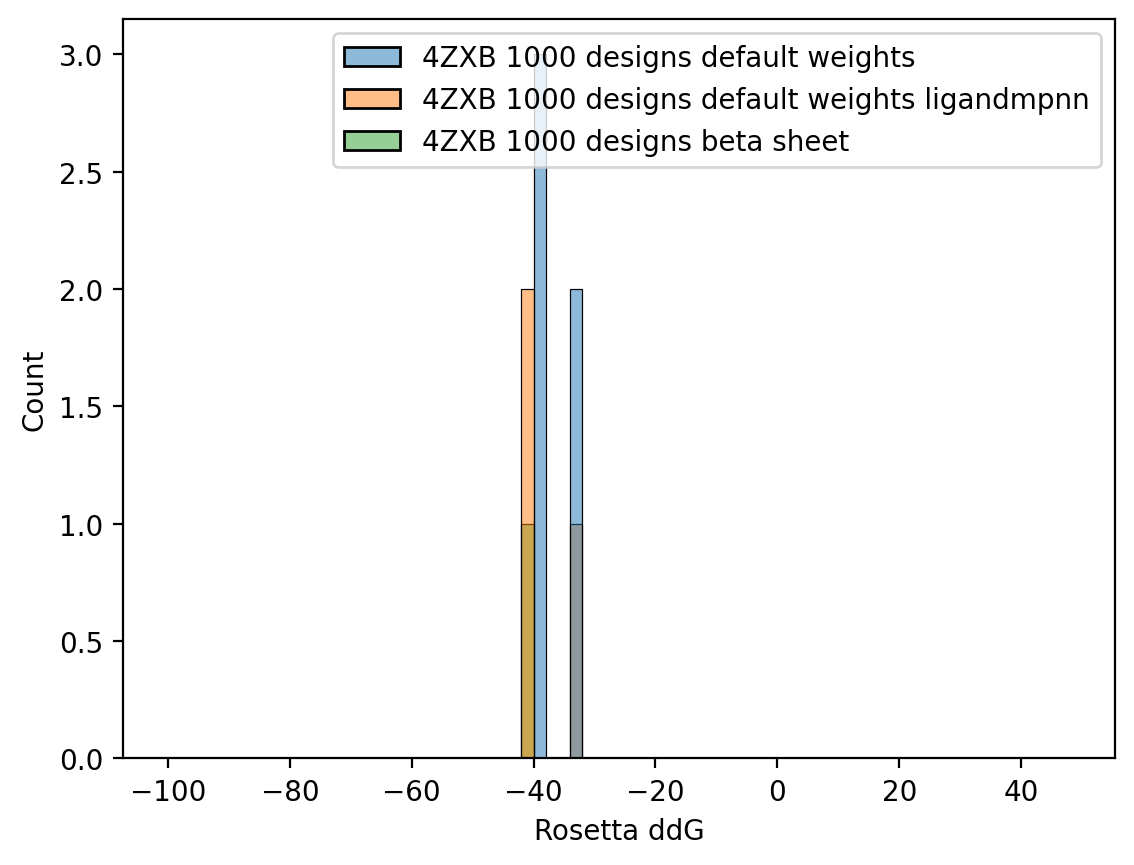

In [15]:
import numpy as np

hue = jobs[('Pool','name')].loc[rf_binder_designs.pool_id]
sns.histplot(rf_binder_designs, x='Rosetta ddG', hue=hue.values, bins=np.arange(-100, 50, 2));

In [16]:
accepted_rf_binder_designs = rf_binder_designs[rf_binder_designs['accepted']]
accepted_rf_binder_designs

,pool_id,structure_path,structure_descriptor_key,accepted,spec,contig_index,Sequence B,Sequence L,Sequence H,Sequence A,...,Normalized positive top1 patch area at pH 7.4,Negative patch area at pH 7.4,Normalized negative patch area at pH 7.4,Negative top1 patch area at pH 7.4,Normalized negative top1 patch area at pH 7.4,Electrostatic volume integral at pH 7.4,Positive electrostatic regions volume integral at pH 7.4,Negative electrostatic regions volume integral at pH 7.4,Positive electrostatic volume integral at pH 7.4,Negative electrostatic volume integral at pH 7.4
id,,,,,,,,,,,,,,,,,,,,,
ovo_avz_0030_cycle02,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,EEEEKYEKLAEVALYGNELVESIKDEEEKEKLAKYVLEVIENREKI...,...,0.008814,2397.582566,0.517766,2397.582566,0.517766,-53204.939693,247.264672,-37802.189478,524.728685,-53729.668377
ovo_avz_0124_cycle04,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,KEEELEKLAYEYLEYSIKSYEYKKKAEELEKSEYEDEEKKKKEIEE...,...,0.002133,1329.886461,0.221943,494.351643,0.082502,-29282.013327,1603.259674,-20382.537688,5073.431641,-34355.444969
ovo_avz_0299_cycle01,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,MSIEEIKKILEEIKKEAEAKNAKKVAEAAAKDPELAKKLAAELTAE...,...,0.013346,1431.141721,0.264025,1222.315483,0.225499,-31439.230457,1221.440562,-21455.968271,3326.778095,-34766.008552
ovo_avz_0481_cycle03,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,MEAALKAAEEEKEFQKQVELAKLMIESYKKEGDEEQAEYWEKILEE...,...,0.004164,2322.248872,0.491070,2295.299667,0.485372,-62153.827602,169.365019,-47174.741642,462.410420,-62616.238021
ovo_avz_0732_cycle04,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,EEEEKEKKLKELEKQAKEVEEEGRKKVKEAEAKLKAGDKSEEVKEL...,...,0.026966,1342.739388,0.243623,1156.812464,0.209889,-18930.954449,6064.660410,-19659.415027,11991.801964,-30922.756413
ovo_bbc_0385_seq4,bbc,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|ligandmpnn|sequence_structure_path,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,MSEVSEKTYEILKKYADSEESLLEGLKIALKEIEKERKYIDEDQLE...,...,0.050660,1593.451988,0.297579,690.407233,0.128934,-22964.616756,4640.841690,-19601.870041,8578.619584,-31543.236340
ovo_bbc_0388_seq1,bbc,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|ligandmpnn|sequence_structure_path,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,MPFEERLKLAKETAKELKEEIEKEKDEEAKKKLQELLDILEKTLKE...,...,0.031025,1309.730849,0.305762,496.236589,0.115848,-21284.751527,2444.493582,-15861.385469,5027.644946,-26312.396472
ovo_bbc_0388_seq3,bbc,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|ligandmpnn|sequence_structure_path,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,MPFEERLEIAKKTAEELKKEIEKEKDEEAKKQLEELLKLLEETLKK...,...,0.018297,1637.702058,0.382422,1636.850651,0.382223,-32095.566216,1328.163742,-23154.548375,3193.993927,-35289.560144
ovo_mmo_0951_cycle02,mmo,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,MTIPEEILKQLEKLKKLAKESNVFDVEFKIVQNEDGSWSIEVVVKE...,...,0.027156,1385.199046,0.249139,673.281612,0.121095,-23669.266951,4127.009359,-20027.421342,8435.121421,-32104.388371


In [17]:
accepted_rf_binder_designs['Rosetta ddG']

id
ovo_avz_0030_cycle02   -38.108719
ovo_avz_0124_cycle04   -39.804649
ovo_avz_0299_cycle01   -33.983391
ovo_avz_0481_cycle03   -39.449741
ovo_avz_0732_cycle04   -33.147793
ovo_bbc_0385_seq4      -40.092587
ovo_bbc_0388_seq1      -32.078648
ovo_bbc_0388_seq3      -40.281807
ovo_mmo_0951_cycle02   -40.518124
Name: Rosetta ddG, dtype: float64

In [18]:
rf_partial_jobs = jobs.loc[['qki']]
rf_partial_jobs

Pool  \
                                       name   
('Pool', 'id')                                
qki             Top designs diversification   

                                                             Job  \
                                              description status   
('Pool', 'id')                                                     
qki             Top 2 from each pool by PAE, RMSD and ddG   Done   

                              Designs       Workflow  \
                     created accepted total    input   
('Pool', 'id')                                         
qki             4 months ago       37    37      NaN   

                                           \
                                     type   
('Pool', 'id')                              
qki             RFdiffusion binder design   

                                                      RFdiffusion  \
                                                          contigs   
('Pool', 'id')                                                      
qki             ['62-62/0 B6-155', '71-71/0 B6-155', '70-70/0 ...   

                             ...               BindCraft                   \
                   hotspots  ... number_of_final_designs time_limit_hours   
('Pool', 'id')               ...                                            
qki             B64,B88,B96  ...                     NaN              NaN   

                                                               \
               filter_type design_protocol interface_protocol   
('Pool', 'id')                                                  
qki                    NaN             NaN                NaN   

                                                                               \
               template_protocol prediction_protocol custom_advanced_settings   
('Pool', 'id')                                                                  
qki                          NaN                 NaN                      NaN   

                                                    
               custom_filter_settings num_replicas  
('Pool', 'id')                                      
qki                               NaN          NaN  

[1 rows x 49 columns]

In [19]:
rf_partial_jobs = jobs.loc[['qki']]

In [20]:
rf_partial_jobs[[
    ('Pool','name'), ('RFdiffusion', 'contigs'), ('RFdiffusion', 'hotspots'), ('RFdiffusion', 'num_designs'), 
    ('ProteinMPNN', 'num_sequences'), ('ProteinMPNN', 'fastrelax_cycles')
]]

Pool  \
                                       name   
('Pool', 'id')                                
qki             Top designs diversification   

                                                      RFdiffusion  \
                                                          contigs   
('Pool', 'id')                                                      
qki             ['62-62/0 B6-155', '71-71/0 B6-155', '70-70/0 ...   

                                          ProteinMPNN                   
                   hotspots num_designs num_sequences fastrelax_cycles  
('Pool', 'id')                                                          
qki             B64,B88,B96        50.0           1.0              2.0

In [21]:
rf_partial_jobs[['Pool', 'Designs', 'Thresholds']].dropna(how='all', axis=1)

Pool  \
                                       name   
('Pool', 'id')                                
qki             Top designs diversification   

                                                           Designs        \
                                              description accepted total   
('Pool', 'id')                                                             
qki             Top 2 from each pool by PAE, RMSD and ddG       37    37   

               Thresholds                                                  \
                 AF2 iPAE AF2 Target-aligned Binder RMSD AF2 Binder pLDDT   
('Pool', 'id')                                                              
qki              ≤ 10.000                        ≤ 2.000         ≥ 80.000   

                            
               Rosetta ddG  
('Pool', 'id')              
qki              ≤ -30.000

In [22]:
rf_partial_jobs[('RFdiffusion','contigs')].iloc[0]

"['62-62/0 B6-155', '71-71/0 B6-155', '70-70/0 B6-155']"

In [23]:
rf_partial_designs = designs[designs['pool_id'].isin(['qki'])]
rf_partial_designs.head()

,pool_id,structure_path,structure_descriptor_key,accepted,spec,contig_index,Sequence B,Sequence L,Sequence H,Sequence A,...,Normalized positive top1 patch area at pH 7.4,Negative patch area at pH 7.4,Normalized negative patch area at pH 7.4,Negative top1 patch area at pH 7.4,Normalized negative top1 patch area at pH 7.4,Electrostatic volume integral at pH 7.4,Positive electrostatic regions volume integral at pH 7.4,Negative electrostatic regions volume integral at pH 7.4,Positive electrostatic volume integral at pH 7.4,Negative electrostatic volume integral at pH 7.4
id,,,,,,,,,,,,,,,,,,,,,
ovo_qki_01_01_cycle01,qki,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,EEEERAERLADLMLRANELAESQESEEDREKLIALAEEILEDEEAL...,...,0.000204,3575.630396,0.777068,3573.380175,0.776579,-83149.918255,18.991748,-66534.429361,51.628696,-83201.546952
ovo_qki_01_11_cycle02,qki,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,SEEEKLEEFWEVVQLWHEAALAAPTPEASQRIIDYLNELLLDLEKA...,...,NaN,1526.624412,0.350490,874.812494,0.200844,-43039.746728,35.366980,-27783.255916,145.986638,-43185.733366
ovo_qki_01_14_cycle01,qki,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,EEEEIWEKFAEIALELNEEFEKSGDEEAMKIAEKILDEMLDNPEKI...,...,NaN,3128.260627,0.694402,3128.260627,0.694402,-65406.967614,29.286985,-49762.955262,104.353135,-65511.320748
ovo_qki_01_15_cycle02,qki,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,MEREKLLLLWESMELGQKVIEKTKDEELKKKVIEEVDKLIDDEELL...,...,0.008937,1424.381815,0.294227,1053.105138,0.217534,-30181.031052,1257.924646,-21542.964534,3272.441808,-33453.472860
ovo_qki_01_21_cycle03,qki,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,NaN,NaN,NaN,MELEGWENVMNALLELNKLAEKAKTEEEKKAYLEKGEEIIKNPEKY...,...,0.003364,1234.621555,0.270786,586.255949,0.128582,-25374.978251,960.625944,-15912.187385,2598.117097,-27973.095349


In [24]:
accepted_rf_partial_designs = rf_partial_designs[rf_partial_designs['accepted']]
accepted_rf_partial_designs['contig_index'].value_counts()

contig_index
0    17
1    13
2     7
Name: count, dtype: int64

The workflow was applied to design a miniprotein binder of 50 to 100 residues against insulin receptor PDB 4ZXB chain E residues 6-155, targetting hotspot residues 64, 88 and 96. In total, 1000 backbones * 3 ProteinMPNN FastRelax steps (+ 1 initial ProteinMPNN design) were generated, totaling at 4000 generated sequences, which were filtered with AlphaFold2 (iPAE < 10, pLDDT > 80, Target-aligned Binder RMSD < 2 A) and Rosetta (ddG < -30), resulting in 5 accepted designs. The same workflow with beta sheet RFdiffusion model weights yielded 1 accepted design with 20% of the structure forming beta sheets. 

Running partial diffusion (50 backbones * 2 fastrelax steps) on three most AF2 confident RFdiffusion designs demonstrated the applicability of partial diffusion to exploit similar areas of structure space - 37 out of 450 designs were accepted by the default AlphaFold2 and Rosetta thresholds, corresponding to 8.2% in silico success rate compared to 0.075% success rate of the 6/8000 designs accepted by the de novo designs.

In [25]:
bindcraft_jobs = jobs.loc[['rsj']]
bindcraft_jobs[['Pool','Designs','BindCraft']]

Pool  \
                                  name   
('Pool', 'id')                           
rsj             4ZXB BindCraft default   

                                                                   Designs  \
                                                      description accepted   
('Pool', 'id')                                                               
rsj             Insulin receptor miniprotein binders hotspot E...       13   

                         BindCraft                             \
               total target_chains binder_length     hotspots   
('Pool', 'id')                                                  
rsj               13             E        50,100  E64,E88,E96   

                                                                     \
               number_of_final_designs time_limit_hours filter_type   
('Pool', 'id')                                                        
rsj                               20.0              6.0     Default   

                                                                     \
               design_protocol interface_protocol template_protocol   
('Pool', 'id')                                                        
rsj                    Default         AlphaFold2           Default   

                                                             \
               prediction_protocol custom_advanced_settings   
('Pool', 'id')                                                
rsj                        Default                       {}   

                                                    
               custom_filter_settings num_replicas  
('Pool', 'id')                                      
rsj                                {}          1.0

In [26]:
# from ovo import db

# for j in db.DesignJob.select():
#     pool = db.Pool.get(design_job_id=j.id)
#     print(pool.name, j.job_id)

Designing a miniprotein binder of 50 to 100 residues against insulin receptor PDB 4ZXB chain E residues 6-155, targeting hotspot residues 64, 88 and 96. Running for 6 hours on 1 A10G GPU yielded 13 designs accepted by default AlphaFold2 and Rosetta filters and 95 designs rejected by AlphaFold2 filters. No trajectories were rejected during design protocol, which could be attributed to AlphaFold2's preference of the selected target epitope.


Figura 2 completada y exportada.


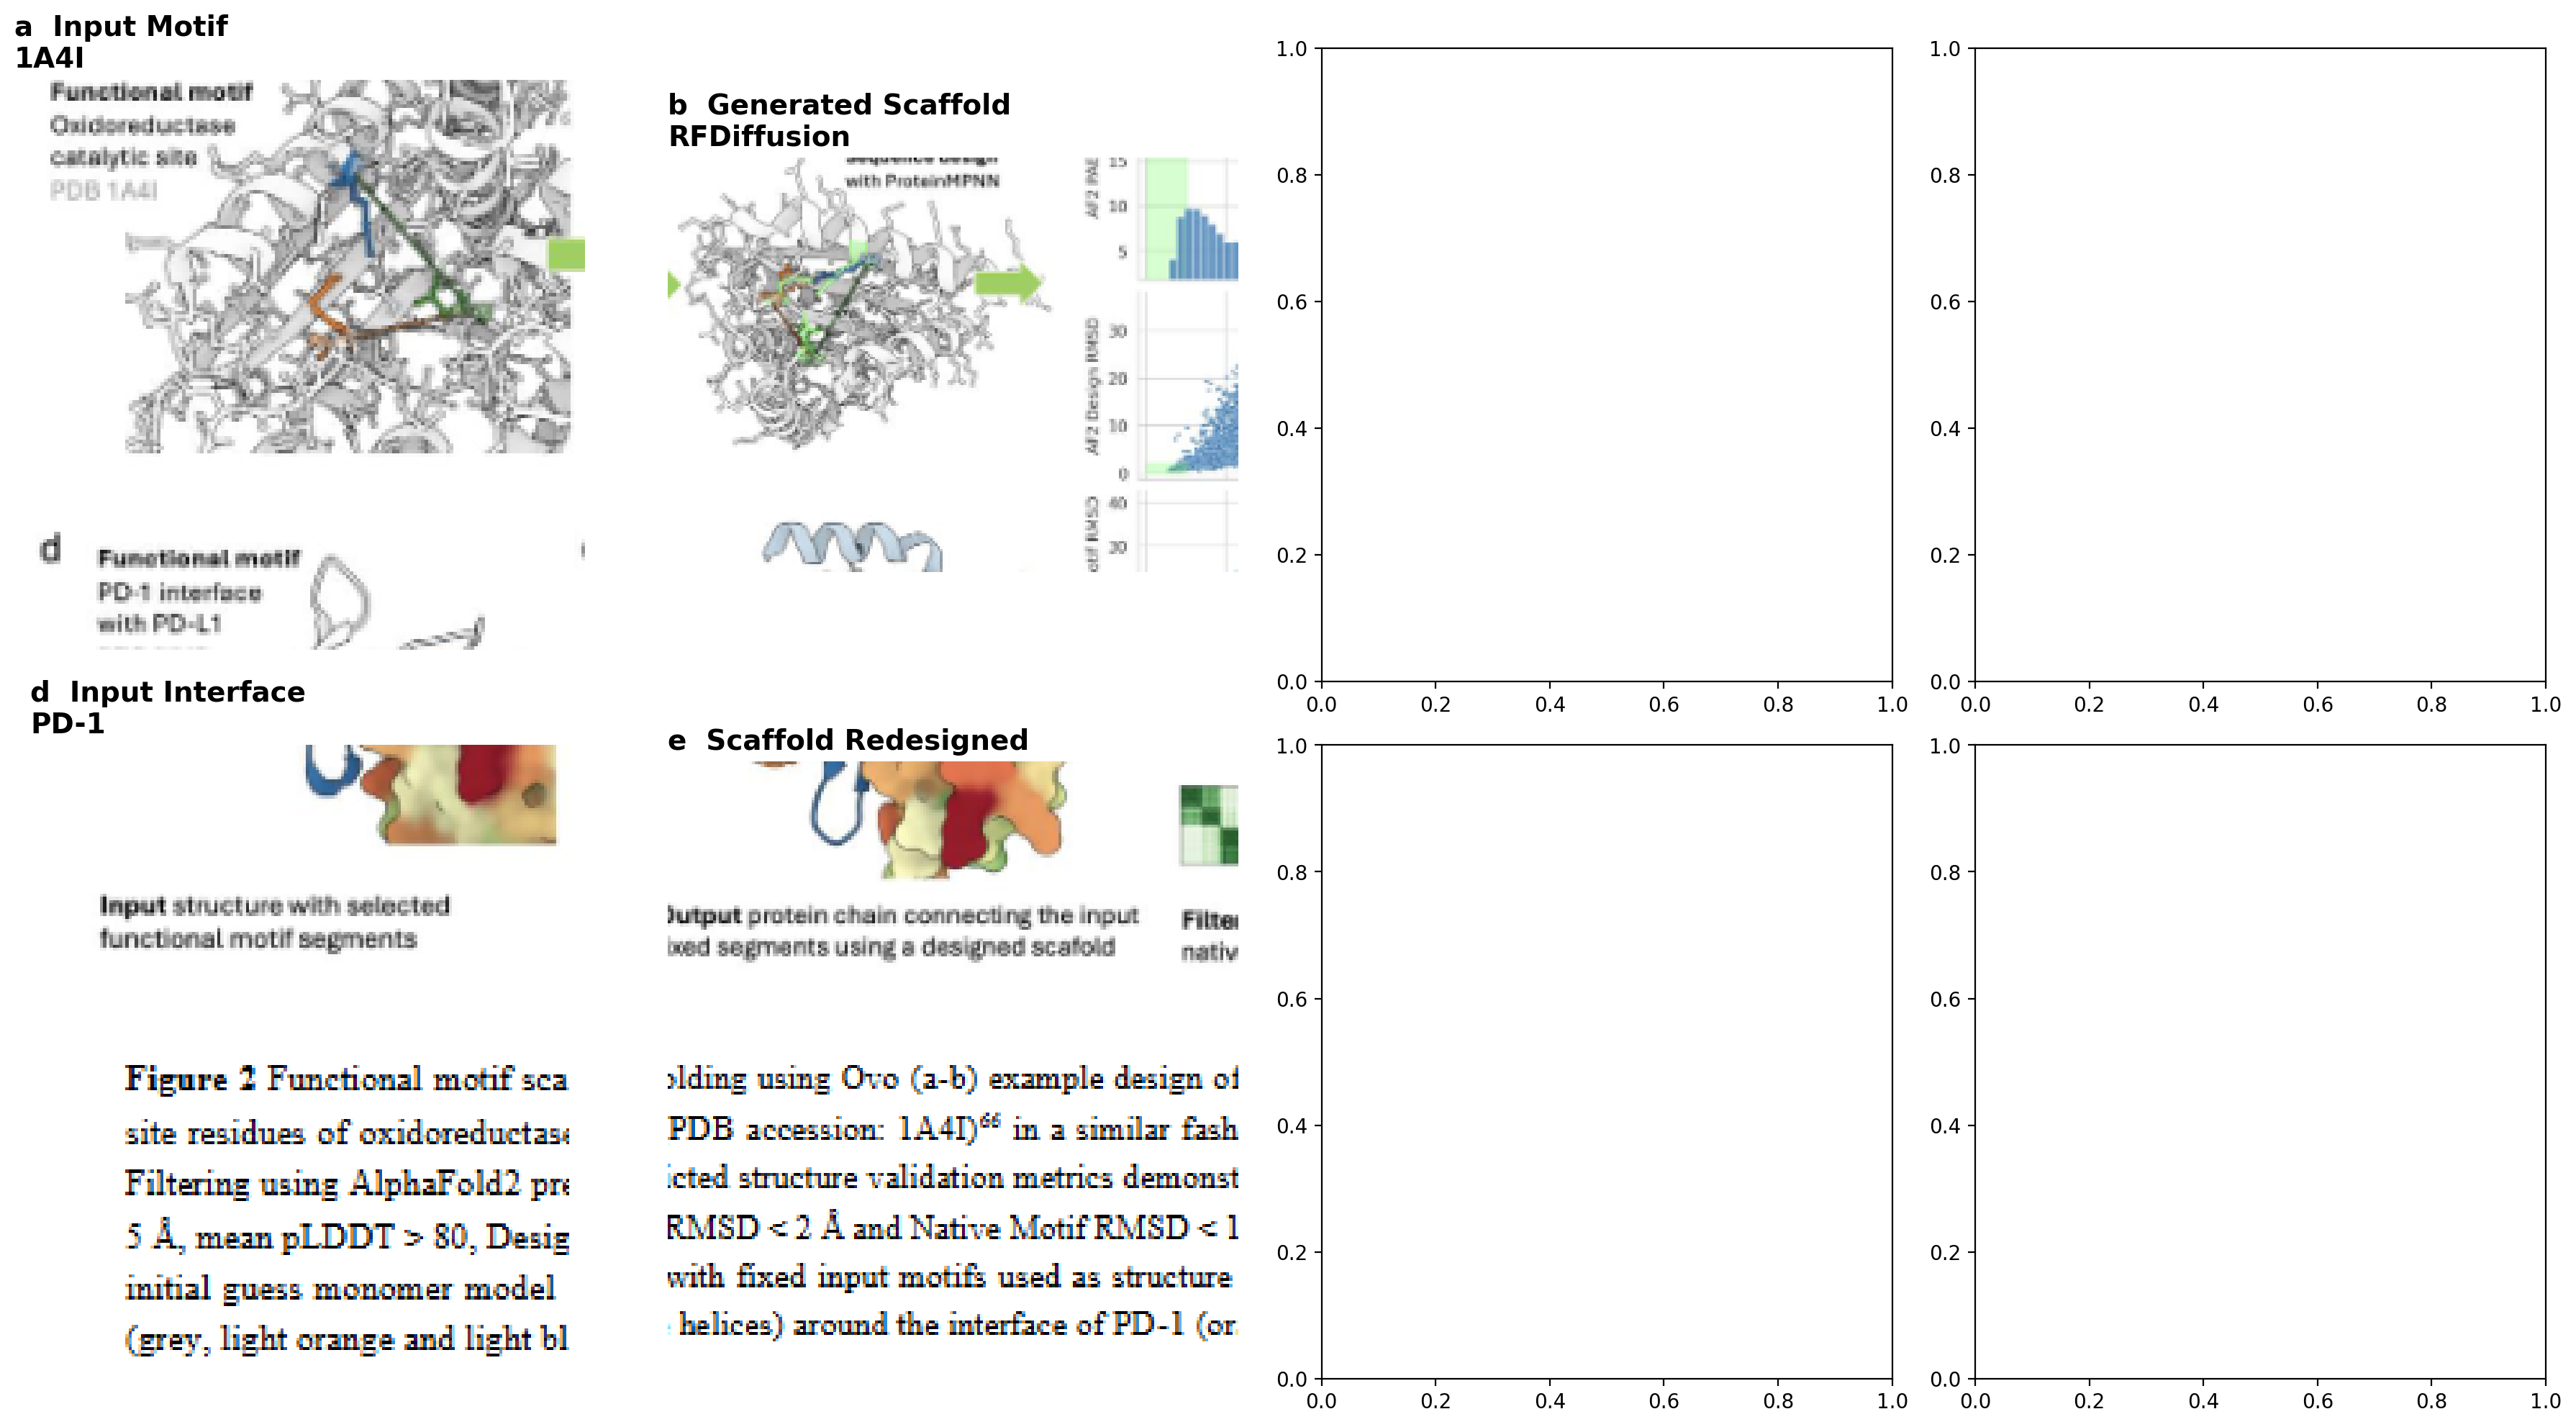

In [27]:

# COMPOSICIÓN DE LA FIGURA 2 COMPLETA DEL PAPER OVO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import os
import seaborn as sns

# 1. Cargar las imagenes 3D extraidas del documento original
paper_img_path = r'C:\Users\PC\.gemini\antigravity\brain\4e9035ee-e91a-44e4-9d8d-45c50fe12f24\media__1773203832398.png'
original_img = Image.open(paper_img_path)

# Recortes aproximados del 3D a partir de la imagen (ajustado para resolucion 670x568)
box_a = (30, 100, 190, 260)
box_b = (200, 100, 420, 260)   # Más ancho para que quepa bien
box_d = (20, 320, 190, 520)
box_e = (200, 320, 390, 520)

img_a = original_img.crop(box_a)
img_b = original_img.crop(box_b)
img_d = original_img.crop(box_d)
img_e = original_img.crop(box_e)

# 2. Cargar nuestras gráficas de dispersion generadas en este mismo cuaderno
fig = plt.figure(figsize=(18, 10))

# Fila 1 (Oxidoreductasa): Columna 1 (prot a), Columna 2 (prot b), Columnas 3-4 (scatter plots c)
ax1 = plt.subplot(2, 4, 1)
ax1.imshow(img_a)
ax1.axis('off')
ax1.set_title('a  Input Motif\n1A4I', loc='left', fontsize=14, fontweight='bold')

ax2 = plt.subplot(2, 4, 2)
ax2.imshow(img_b)
ax2.axis('off')
ax2.set_title('b  Generated Scaffold\nRFDiffusion', loc='left', fontsize=14, fontweight='bold')

# Vamos a graficar nuestros propios scatter plots aqui mismo como parte del script
ax3 = plt.subplot(2, 4, 3)
if "scaffolds_df" in locals():
    sns.scatterplot(data=scaffolds_df, x='af2_pae', y='af2_design_rmsd', hue='is_accepted', ax=ax3, s=20, alpha=0.6, legend=False)
    ax3.set_xlabel('AF2 PAE')
    ax3.set_ylabel('AF2 Design RMSD')
    ax3.set_title('c  OVO Replicated Metrics', loc='left', fontsize=14, fontweight='bold')

ax4 = plt.subplot(2, 4, 4)
if "scaffolds_df" in locals():
    sns.scatterplot(data=scaffolds_df, x='af2_design_rmsd', y='af2_native_motif_rmsd', hue='is_accepted', ax=ax4, s=20, alpha=0.6, legend=False)
    ax4.set_xlabel('AF2 Design RMSD')
    ax4.set_ylabel('AF2 Native Motif RMSD')

ax5 = plt.subplot(2, 4, 5)
ax5.imshow(img_d)
ax5.axis('off')
ax5.set_title('d  Input Interface\nPD-1', loc='left', fontsize=14, fontweight='bold')

ax6 = plt.subplot(2, 4, 6)
ax6.imshow(img_e)
ax6.axis('off')
ax6.set_title('e  Scaffold Redesigned', loc='left', fontsize=14, fontweight='bold')

ax7 = plt.subplot(2, 4, 7)
if "af2_interface" in locals():
    sns.scatterplot(data=af2_interface, x='plddt', y='pae', hue='is_accepted', ax=ax7, s=20, alpha=0.6, legend=False)
    ax7.set_xlabel('pLDDT')
    ax7.set_ylabel('PAE')
    
ax8 = plt.subplot(2, 4, 8)
if "af2_interface" in locals():
    sns.scatterplot(data=af2_interface, x='pae', y='rmsd', hue='is_accepted', ax=ax8, s=20, alpha=0.6, legend=False)
    ax8.set_xlabel('PAE')
    ax8.set_ylabel('RMSD')

plt.tight_layout()

# Guardar figura
out_path = r'd:\ProyectosUniversidad\BioInformatica\PaperReplicado\figuras\gen_figura_2_completa_colab.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"Figura 2 completada y exportada.")

